In [1]:
# ============================================================
# ANALÝZA ČASOVÝCH ŘAD MĚŘENÍ PŘI 25 PPM N2O – NDIR vs. QCL TDLAS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# ------------------------------------------------------------
# 1) Načtení zaokrouhlených CSV dat
# ------------------------------------------------------------
df = pd.read_csv("N2O_NDIR_QCL_90min_rounded.csv", sep=";")

t = df["time_s"].values
x_ndir = df["ndir_ppm"].values
x_qcl  = df["qcl_ppm"].values

print("Počet vzorků:", len(df))


Počet vzorků: 1081


C:\Users\venan\AppData\Local\Temp\ipykernel_4592\434013632.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


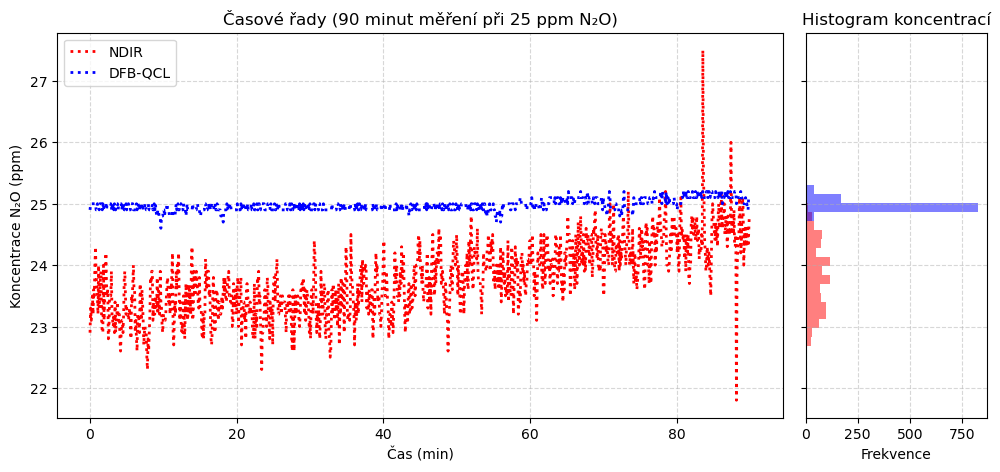

In [2]:
# ------------------------------------------------------------
# 2) Časová řada + vertikální histogram
# ------------------------------------------------------------
fig = plt.figure(figsize=(12,5))
gs = GridSpec(1, 2, width_ratios=[4, 1], wspace=0.05)

# --- Časová řada ---
ax_ts = fig.add_subplot(gs[0])
ax_ts.plot((t - t[0]) / 60, x_ndir, label="NDIR", lw=2, ls=":", color="red")
ax_ts.plot((t - t[0]) / 60, x_qcl, label="DFB-QCL", lw=2, ls=":", color="blue")
ax_ts.set_xlabel("Čas (min)")
ax_ts.set_ylabel("Koncentrace N₂O (ppm)")
ax_ts.set_title("Časové řady (90 minut měření při 25 ppm N₂O)")
ax_ts.grid(True, ls="--", alpha=0.5)
ax_ts.legend()

# --- Histogram se společnými intervaly ---
xmin = min(x_ndir.min(), x_qcl.min())
xmax = max(x_ndir.max(), x_qcl.max())
bins = np.linspace(xmin, xmax, 40)

ax_hist = fig.add_subplot(gs[1], sharey=ax_ts)
ax_hist.hist(x_ndir, bins=bins, orientation="horizontal", alpha=0.5, color="red", label="NDIR")
ax_hist.hist(x_qcl, bins=bins, orientation="horizontal", alpha=0.5, color="blue", label="DFB-QCL")
ax_hist.set_xlabel("Frekvence")
ax_hist.set_title("Histogram koncentrací")
ax_hist.grid(True, ls="--", alpha=0.5)
plt.setp(ax_hist.get_yticklabels(), visible=False)

plt.tight_layout()
plt.show()

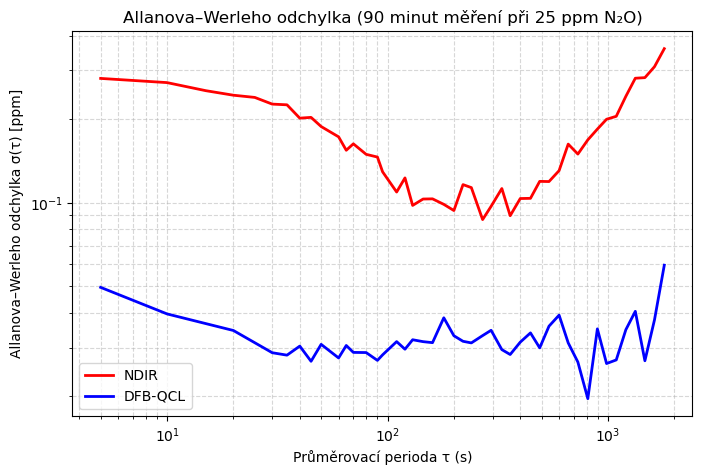

In [3]:
# ------------------------------------------------------------
# 3) Allan–Werle odchylka
# ------------------------------------------------------------
def allan_werle(x, dt):
    N = len(x)
    max_m = N // 3
    m_values = np.unique(np.logspace(0, np.log10(max_m), 60).astype(int))
    taus = m_values * dt
    adev = []

    for m in m_values:
        if 2*m >= N:
            break
        y = np.array([np.mean(x[i:i+m]) for i in range(0, N-m, m)])
        dy = np.diff(y)
        adev.append(np.sqrt(0.5 * np.mean(dy**2)))

    return taus[:len(adev)], np.array(adev)

dt = t[1] - t[0]

tau_ndir, adev_ndir = allan_werle(x_ndir, dt)
tau_qcl, adev_qcl   = allan_werle(x_qcl, dt)

plt.figure(figsize=(8,5))
plt.loglog(tau_ndir, adev_ndir, ls="-", label="NDIR", lw=2, color="red")
plt.loglog(tau_qcl, adev_qcl, ls="-", label="DFB-QCL", lw=2, color="blue")
plt.xlabel("Průměrovací perioda τ (s)")
plt.ylabel("Allanova–Werleho odchylka σ(τ) [ppm]")
plt.title("Allanova–Werleho odchylka (90 minut měření při 25 ppm N₂O)")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.show()
